# Q1 — How consistent are ratings across platforms?

Distribution of the rating spread plus **pairwise** agreement. Multiple views: a summary
(overall and split by 2- vs 3-platform coverage), the spread histogram, cumulative
tolerance bands, and per-pair agreement.

In [1]:
from analysis.notebook import *

Connected to ClickHouse db='dataman' at localhost:8123


In [2]:
q1_sum = publish(run(queries.q1_summary()), "q1_consistency_summary",
                 "Q1 — Rating-spread summary, overall and by platform coverage.")
q1_sum

,coverage,restaurants,mean_range,sd_range,p90_range,max_range,pct_within_0_5,pct_within_1_0
0,,4070,0.518,0.478,1.1,3.80,65.1,89.6
1,2,3341,0.515,0.502,1.1,3.80,66.6,89.1
2,3,729,0.537,0.346,1.0,2.35,57.9,92.2


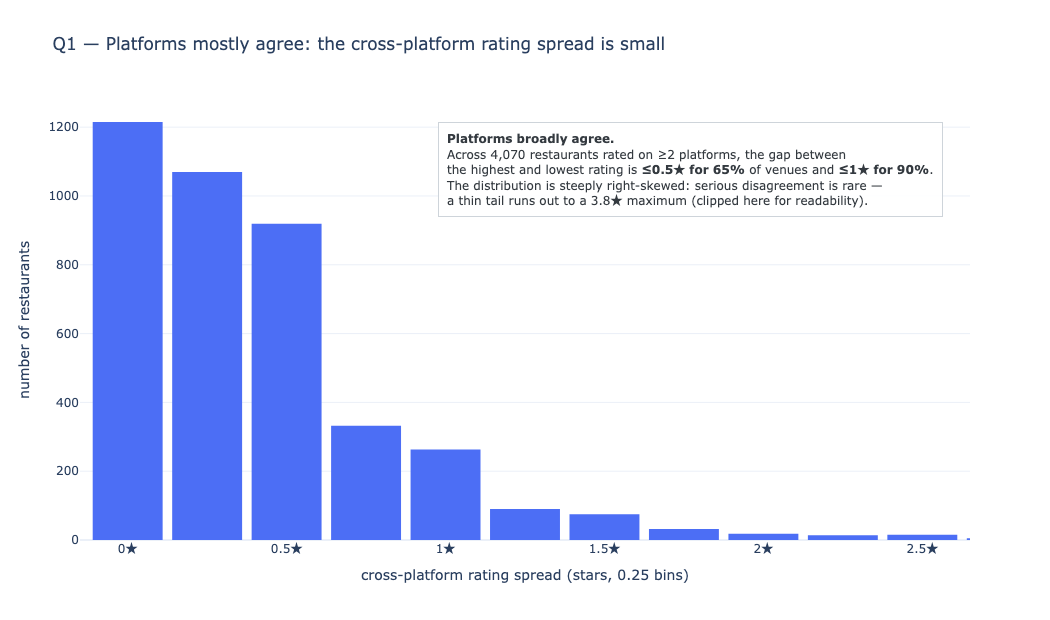

In [3]:
# Q1 — distribution of the cross-platform rating spread (max − min rating across the
# platforms a venue is rated on). The SQL already aggregates into 0.25★ bins, so this is a
# bar-of-counts (a pre-binned histogram) — NOT px.histogram, which would try to re-bin.
q1_hist = run(queries.q1_histogram())

# NB: with two numeric columns px.bar auto-detects orientation="h", which drew the bars as
# horizontal lines; orientation="v" forces the intended vertical histogram.
fig = px.bar(
    q1_hist, x="range_bin", y="restaurants", orientation="v",
    labels={"range_bin": "cross-platform rating spread (stars, 0.25 bins)",
            "restaurants": "number of restaurants"},
    title="Q1 — Platforms mostly agree: the cross-platform rating spread is small",
    template="plotly_white",
)
# Solid colour + an explicit bar width just under the 0.25 bin size for clean separation,
# and clip the long, near-empty right tail so the bulk of the mass (p90 = 1.1★) is legible.
fig.update_traces(
    marker_color="#4C6EF5", marker_line_width=0, width=0.22,
    hovertemplate="spread ≈ %{x:.2f}★<br>%{y:,} restaurants<extra></extra>",
)
fig.update_xaxes(range=[-0.15, 2.65], dtick=0.5, ticksuffix="★")
fig.update_yaxes(rangemode="tozero")

# --- storytelling caption, drawn on the figure (top-right, where the chart is empty) ---
_tot = q1_sum.loc[q1_sum["restaurants"].idxmax()]  # ROLLUP total row from the summary above
fig.add_annotation(
    xref="paper", yref="paper", x=0.97, y=0.95, xanchor="right", yanchor="top",
    align="left", showarrow=False, borderpad=8, borderwidth=1, bordercolor="#CED4DA",
    bgcolor="rgba(255,255,255,0.88)", font=dict(size=12, color="#343A40"),
    text=(
        "<b>Platforms broadly agree.</b><br>"
        f"Across {int(_tot['restaurants']):,} restaurants rated on ≥2 platforms, the gap between<br>"
        f"the highest and lowest rating is <b>≤0.5★ for {_tot['pct_within_0_5']:.0f}%</b> of venues "
        f"and <b>≤1★ for {_tot['pct_within_1_0']:.0f}%</b>.<br>"
        "The distribution is steeply right-skewed: serious disagreement is rare —<br>"
        f"a thin tail runs out to a {_tot['max_range']:.1f}★ maximum (clipped here for readability)."
    ),
)
fig.show()


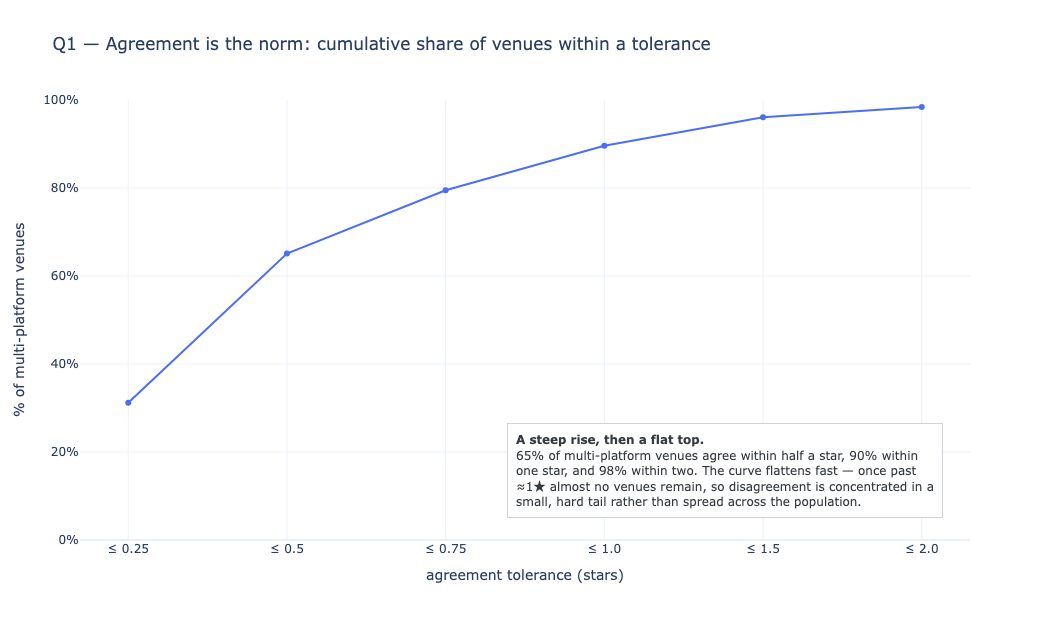

In [4]:
bands = run(queries.q1_tolerance_bands())
band_long = bands.drop(columns=["multi_platform_restaurants"]).T.reset_index()
band_long.columns = ["band", "pct_within"]
band_long["band"] = band_long["band"].str.replace("within_", "≤ ").str.replace("_", ".")
fig = px.line(band_long, x="band", y="pct_within", markers=True,
              labels={"band": "agreement tolerance (stars)", "pct_within": "% of multi-platform venues"},
              title="Q1 — Agreement is the norm: cumulative share of venues within a tolerance",
              template="plotly_white")
fig.update_traces(line_color="#4C6EF5", marker_color="#4C6EF5")
fig.update_yaxes(range=[0, 100], ticksuffix="%")


def _band_pct(label):
    return float(band_long.loc[band_long["band"] == label, "pct_within"].iloc[0])


# --- storytelling caption, drawn on the figure (bottom-right, under the rising curve) ---
fig.add_annotation(
    xref="paper", yref="paper", x=0.97, y=0.05, xanchor="right", yanchor="bottom",
    align="left", showarrow=False, borderpad=8, borderwidth=1, bordercolor="#CED4DA",
    bgcolor="rgba(255,255,255,0.88)", font=dict(size=12, color="#343A40"),
    text=(
        "<b>A steep rise, then a flat top.</b><br>"
        f"{_band_pct('≤ 0.5'):.0f}% of multi-platform venues agree within half a star, "
        f"{_band_pct('≤ 1.0'):.0f}% within<br>one star, and {_band_pct('≤ 2.0'):.0f}% within two. "
        "The curve flattens fast — once past<br>≈1★ almost no venues remain, so disagreement is "
        "concentrated in a<br>small, hard tail rather than spread across the population."
    ),
)
fig.show()


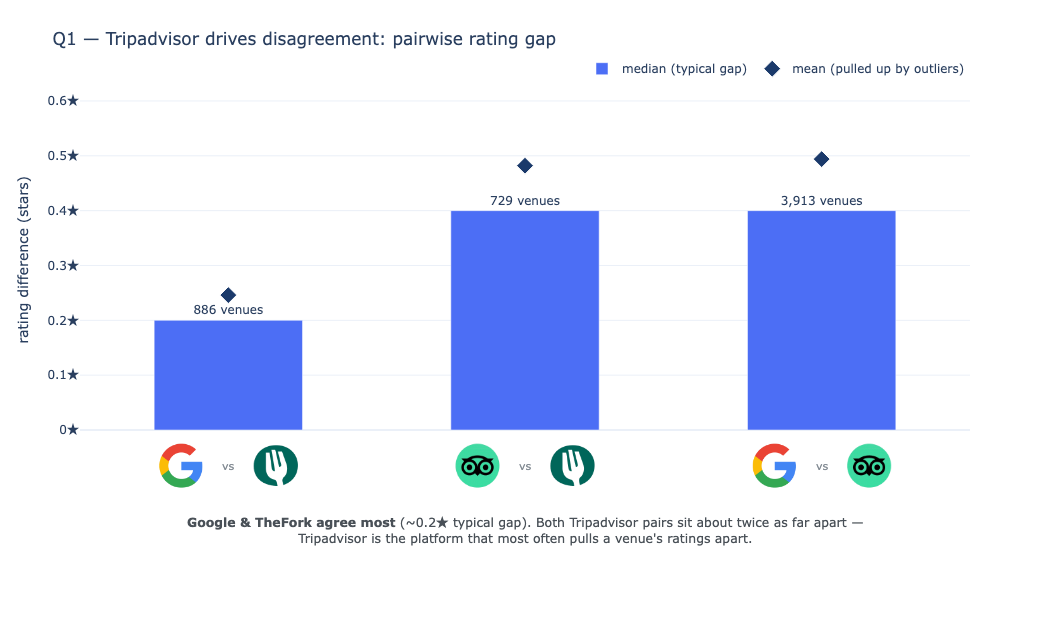

,pair,venues,mean_abs_diff,median_abs_diff,pct_within_0_5,pct_within_1_0
0,google vs thefork,886,0.246,0.2,92.7,99.2
1,google vs tripadvisor,3913,0.494,0.4,66.9,89.9
2,tripadvisor vs thefork,729,0.482,0.4,62.0,92.3


In [5]:
import base64
import pathlib

import plotly.graph_objects as go

q1_pair = publish(run(queries.q1_pairwise_agreement()), "q1_pairwise_agreement",
                  "Q1 — Pairwise agreement (mean |diff| and tolerance shares) per platform pair.")

# Platform logos (saved under assets/logos/, trimmed to content and embedded as data URIs
# so the chart is self-contained for HTML export). Resolve the dir by walking up from the
# CWD so it works whether the notebook runs from notebooks/ or the repo root.
_LOGO_DIR = next((b / "assets" / "logos" for b in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                  if (b / "assets" / "logos" / "google.png").exists()), None)


def _logo_uri(name):
    return "data:image/png;base64," + base64.b64encode((_LOGO_DIR / f"{name}.png").read_bytes()).decode()


# A bar chart is right for comparing one magnitude across three category-pairs against a
# zero baseline. |rating diff| is right-skewed with a heavy tail (a few venues disagree by
# up to ~3.8★), so the MEDIAN is the better "typical gap" — bars show the median, and a
# diamond marks the MEAN, which the outliers pull higher. Sorted closest-agreeing first.
d = q1_pair.sort_values("mean_abs_diff").reset_index(drop=True)
pairs = d["pair"].tolist()
xs = list(range(len(pairs)))

fig = go.Figure()
fig.add_bar(x=xs, y=d["median_abs_diff"], width=0.5, marker_color="#4C6EF5",
            name="median (typical gap)", cliponaxis=False,
            text=[f"{v:,} venues" for v in d["venues"]], textposition="outside",
            hovertemplate="median |diff| %{y:.3f}★<extra></extra>")
fig.add_scatter(x=xs, y=d["mean_abs_diff"], mode="markers", name="mean (pulled up by outliers)",
                marker=dict(symbol="diamond", size=13, color="#1B3A6B", line=dict(width=1, color="white")),
                hovertemplate="mean |diff| %{y:.3f}★<extra></extra>")
fig.update_xaxes(tickvals=xs, showticklabels=False, range=[-0.5, len(pairs) - 0.5])
fig.update_yaxes(range=[0, 0.62], ticksuffix="★", title_text="rating difference (stars)")

# Logos in place of text tick labels: the two platforms of each pair, below their bar.
# Logos span paper-y −0.04 → −0.17, so centre the "vs" at −0.105 to sit between them.
for i, pair in enumerate(pairs):
    a, b = pair.split(" vs ")
    for j, plat in enumerate([a, b]):
        fig.add_layout_image(dict(source=_logo_uri(plat), xref="x", yref="paper",
            x=i + (-0.16 if j == 0 else 0.16), y=-0.04, sizex=0.26, sizey=0.13,
            xanchor="center", yanchor="top", sizing="contain", layer="above"))
    fig.add_annotation(x=i, y=-0.105, xref="x", yref="paper", text="vs", showarrow=False,
                       font=dict(size=11, color="#868E96"), yanchor="middle")

fig.update_layout(template="plotly_white", margin=dict(b=190, t=90),
                  title="Q1 — Tripadvisor drives disagreement: pairwise rating gap",
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))

# --- storytelling caption, centred UNDER the whole chart (below the logos) ---
fig.add_annotation(
    xref="paper", yref="paper", x=0.5, y=-0.24, xanchor="center", yanchor="top",
    align="center", showarrow=False, font=dict(size=12.5, color="#495057"),
    text=("<b>Google &amp; TheFork agree most</b> (~0.2★ typical gap). Both Tripadvisor pairs sit about "
          "twice as far apart —<br>Tripadvisor is the platform that most often pulls a venue's ratings apart."),
)
fig.show()
q1_pair


**Answer (Q1):** Most multi-platform venues agree closely — see `q1_consistency_summary`
(`pct_within_0_5`, `pct_within_1_0`). But agreement is **pair-dependent**: Google and
TheFork agree very tightly, whereas Google–Tripadvisor and Tripadvisor–TheFork disagree
noticeably more (`q1_pairwise_agreement`). Tripadvisor is the source that most often pulls
a venue's ratings apart.